# 第31章: ベイズ法

## 学習目標
- ベイズの定理を推論に適用できる
- 事前分布と事後分布を理解する
- 共役事前分布を使用できる
- ベイズ推定を行える
- 信用区間を計算できる
- MAP推定を理解する

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_func, beta as beta_func
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 31.1 ベイズの定理

### 基本形
$$P(\theta | D) = \frac{P(D | \theta) P(\theta)}{P(D)}$$

- $P(\theta)$: 事前分布
- $P(D | \theta)$: 尤度
- $P(\theta | D)$: 事後分布
- $P(D)$: 周辺尤度（正規化定数）

### 比例形
$$P(\theta | D) \propto P(D | \theta) P(\theta)$$

ベイズの定理

データ: 10回中7回表

事前分布: Beta(1, 1)
事後分布: Beta(8, 4)


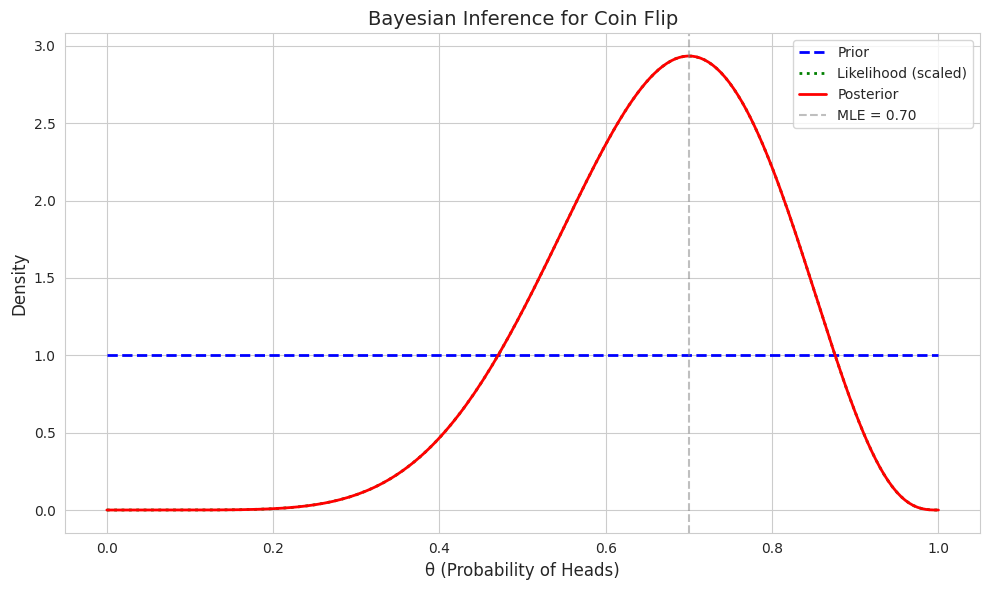

In [2]:
# ベイズの定理の基本例（コイン投げ）
print("ベイズの定理")
print("="*60)

# Data: 10 flips, 7 heads
n = 10
k = 7

# Prior: Beta(1, 1) = Uniform(0, 1)
alpha_prior = 1
beta_prior = 1

# Posterior: Beta(alpha + k, beta + n - k)
alpha_post = alpha_prior + k
beta_post = beta_prior + n - k

print(f"\nデータ: {n}回中{k}回表")
print(f"\n事前分布: Beta({alpha_prior}, {beta_prior})")
print(f"事後分布: Beta({alpha_post}, {beta_post})")

# Visualize
theta = np.linspace(0, 1, 200)

prior = stats.beta.pdf(theta, alpha_prior, beta_prior)
likelihood = stats.binom.pmf(k, n, theta)
posterior = stats.beta.pdf(theta, alpha_post, beta_post)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta, prior, 'b--', linewidth=2, label='Prior')
ax.plot(theta, likelihood / np.max(likelihood) * np.max(posterior), 'g:', linewidth=2, label='Likelihood (scaled)')
ax.plot(theta, posterior, 'r-', linewidth=2, label='Posterior')
ax.axvline(k/n, color='gray', linestyle='--', alpha=0.5, label=f'MLE = {k/n:.2f}')

ax.set_xlabel('θ (Probability of Heads)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title("Bayesian Inference for Coin Flip", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 31.2 共役事前分布

### 定義
事後分布が事前分布と同じ分布族になる事前分布

### 主な共役ペア
| 尤度 | 事前分布 | 事後分布 |
|------|----------|----------|
| 二項分布 | Beta | Beta |
| ポアソン分布 | Gamma | Gamma |
| 正規分布（μ） | Normal | Normal |
| 正規分布（σ²） | Inverse-Gamma | Inverse-Gamma |

共役事前分布: 正規-正規

真のμ: 2
標本平均: 2.045

事前分布: N(0, 10)
事後分布: N(2.038, 0.0332)


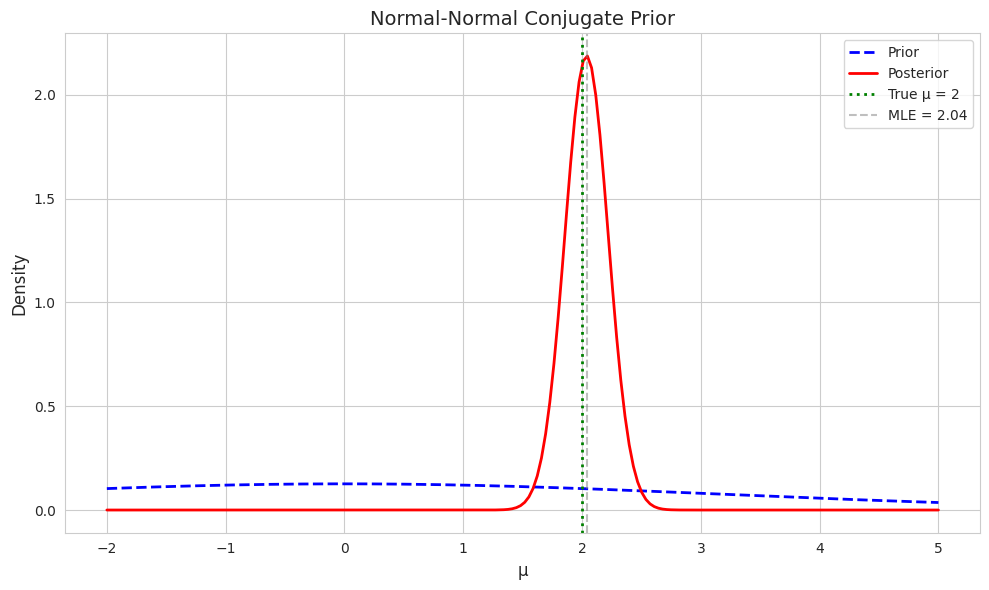

In [3]:
# 正規分布の平均に対する共役事前分布
print("共役事前分布: 正規-正規")
print("="*60)

# Known variance
sigma2 = 1

# Prior: N(mu_0, tau_0^2)
mu_0 = 0
tau_0_2 = 10

# Data
np.random.seed(123)
true_mu = 2
n = 30
data = np.random.normal(true_mu, np.sqrt(sigma2), n)
x_bar = np.mean(data)

# Posterior: N(mu_n, tau_n^2)
tau_n_2 = 1 / (1/tau_0_2 + n/sigma2)
mu_n = tau_n_2 * (mu_0/tau_0_2 + n*x_bar/sigma2)

print(f"\n真のμ: {true_mu}")
print(f"標本平均: {x_bar:.3f}")
print(f"\n事前分布: N({mu_0}, {tau_0_2})")
print(f"事後分布: N({mu_n:.3f}, {tau_n_2:.4f})")

# Visualize
mu_range = np.linspace(-2, 5, 200)

prior_norm = stats.norm.pdf(mu_range, mu_0, np.sqrt(tau_0_2))
posterior_norm = stats.norm.pdf(mu_range, mu_n, np.sqrt(tau_n_2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mu_range, prior_norm, 'b--', linewidth=2, label='Prior')
ax.plot(mu_range, posterior_norm, 'r-', linewidth=2, label='Posterior')
ax.axvline(true_mu, color='green', linestyle=':', linewidth=2, label=f'True μ = {true_mu}')
ax.axvline(x_bar, color='gray', linestyle='--', alpha=0.5, label=f'MLE = {x_bar:.2f}')

ax.set_xlabel('μ', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Normal-Normal Conjugate Prior', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [4]:
# ポアソン-ガンマ共役
print("\n共役事前分布: ポアソン-ガンマ")
print("="*60)

# Prior: Gamma(alpha, beta)
alpha_prior = 2
beta_prior = 1

# Data
true_lambda = 5
n = 20
data_pois = np.random.poisson(true_lambda, n)
sum_x = np.sum(data_pois)

# Posterior: Gamma(alpha + sum(x), beta + n)
alpha_post = alpha_prior + sum_x
beta_post = beta_prior + n

print(f"\n真のλ: {true_lambda}")
print(f"データの合計: {sum_x}")
print(f"\n事前分布: Gamma({alpha_prior}, {beta_prior})")
print(f"事後分布: Gamma({alpha_post}, {beta_post})")
print(f"事後平均: {alpha_post / beta_post:.3f}")


共役事前分布: ポアソン-ガンマ

真のλ: 5
データの合計: 111

事前分布: Gamma(2, 1)
事後分布: Gamma(113, 21)
事後平均: 5.381


## 31.3 ベイズ推定

### 点推定
- **事後平均**: $E[\theta | D]$
- **事後中央値**: $\text{Median}[\theta | D]$
- **MAP推定**: $\arg\max_\theta P(\theta | D)$

### 損失関数との関係
- 二乗損失 → 事後平均
- 絶対損失 → 事後中央値
- 0-1損失 → MAP

ベイズ推定

事後分布: Beta(113, 21)

点推定:
  事後平均: 0.8433
  事後中央値: 0.8450
  MAP (事後最頻値): 0.8485
  MLE: 0.3500


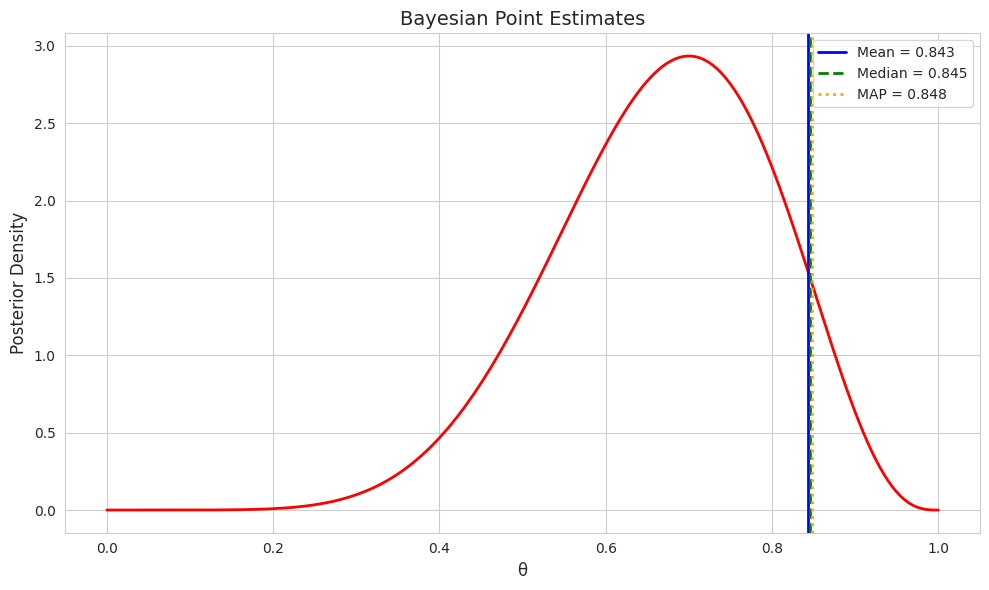

In [5]:
# ベイズ推定の比較
print("ベイズ推定")
print("="*60)

# Use the coin flip example
# Posterior: Beta(8, 4)

# Point estimates
post_mean = alpha_post / (alpha_post + beta_post)
post_mode = (alpha_post - 1) / (alpha_post + beta_post - 2)  # MAP for Beta
post_median = stats.beta.median(alpha_post, beta_post)
mle = k / n

print(f"\n事後分布: Beta({alpha_post}, {beta_post})")
print(f"\n点推定:")
print(f"  事後平均: {post_mean:.4f}")
print(f"  事後中央値: {post_median:.4f}")
print(f"  MAP (事後最頻値): {post_mode:.4f}")
print(f"  MLE: {mle:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta, posterior, 'r-', linewidth=2)
ax.axvline(post_mean, color='blue', linestyle='-', linewidth=2, label=f'Mean = {post_mean:.3f}')
ax.axvline(post_median, color='green', linestyle='--', linewidth=2, label=f'Median = {post_median:.3f}')
ax.axvline(post_mode, color='orange', linestyle=':', linewidth=2, label=f'MAP = {post_mode:.3f}')

ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('Bayesian Point Estimates', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 31.4 信用区間

### 定義
事後分布に基づく区間
$$P(a < \theta < b | D) = 1 - \alpha$$

### 等裾信用区間
両側から$\alpha/2$ずつカット

### 最高事後密度区間 (HPD)
最も狭い信用区間

信用区間

95%等裾信用区間: [0.7774, 0.8995]
区間幅: 0.1222


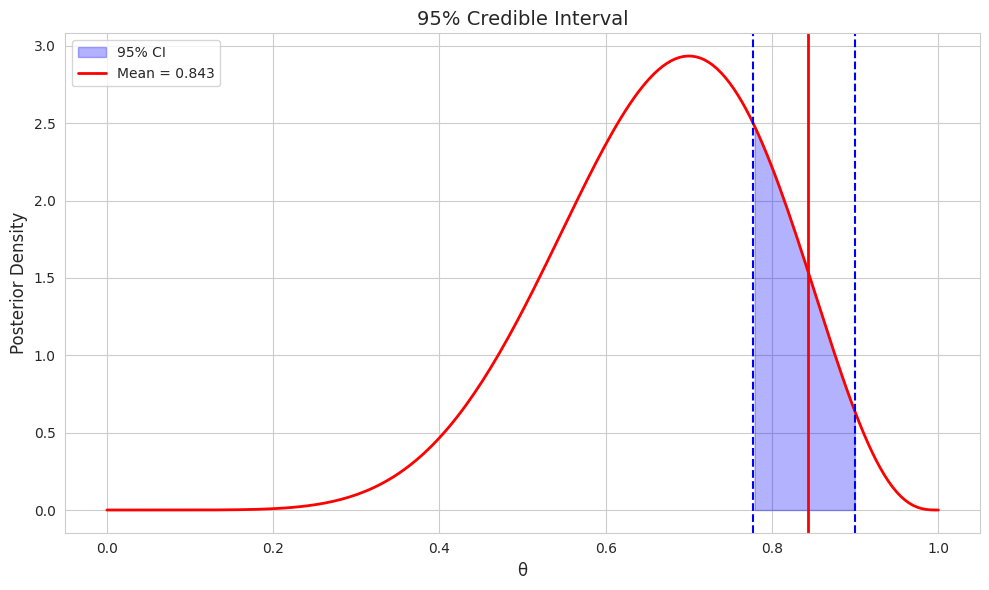

In [6]:
# 信用区間
print("信用区間")
print("="*60)

# 95% Equal-tailed credible interval
ci_lower = stats.beta.ppf(0.025, alpha_post, beta_post)
ci_upper = stats.beta.ppf(0.975, alpha_post, beta_post)

print(f"\n95%等裾信用区間: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"区間幅: {ci_upper - ci_lower:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta, posterior, 'r-', linewidth=2)

# Shade credible interval
mask = (theta >= ci_lower) & (theta <= ci_upper)
ax.fill_between(theta[mask], posterior[mask], alpha=0.3, color='blue', label='95% CI')

ax.axvline(ci_lower, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(ci_upper, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(post_mean, color='red', linestyle='-', linewidth=2, label=f'Mean = {post_mean:.3f}')

ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('95% Credible Interval', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# 信用区間と信頼区間の比較（シミュレーション）
print("\n信用区間 vs 信頼区間")
print("="*60)

np.random.seed(789)
n_sim = 1000
n = 10
true_theta = 0.6

# Coverage check
bayes_coverage = 0
freq_coverage = 0

for _ in range(n_sim):
    # Generate data
    k = np.random.binomial(n, true_theta)
    
    # Bayesian CI (with flat prior)
    alpha_b = 1 + k
    beta_b = 1 + n - k
    bayes_lower = stats.beta.ppf(0.025, alpha_b, beta_b)
    bayes_upper = stats.beta.ppf(0.975, alpha_b, beta_b)
    
    if bayes_lower <= true_theta <= bayes_upper:
        bayes_coverage += 1
    
    # Frequentist CI (Wald)
    p_hat = k / n
    if p_hat > 0 and p_hat < 1:
        se = np.sqrt(p_hat * (1 - p_hat) / n)
        freq_lower = p_hat - 1.96 * se
        freq_upper = p_hat + 1.96 * se
        
        if freq_lower <= true_theta <= freq_upper:
            freq_coverage += 1

print(f"\nカバー率 (真のθ = {true_theta}):")
print(f"  ベイズ信用区間: {bayes_coverage / n_sim:.1%}")
print(f"  頻度論信頼区間: {freq_coverage / n_sim:.1%}")


信用区間 vs 信頼区間



カバー率 (真のθ = 0.6):
  ベイズ信用区間: 97.9%
  頻度論信頼区間: 90.5%


## 31.5 事前分布の選択

### 無情報事前分布
- 一様分布
- Jeffreys事前分布: $p(\theta) \propto \sqrt{I(\theta)}$

### 情報事前分布
- 専門家の知識
- 過去のデータ

### 事前分布の感度分析
異なる事前分布で結果を比較

事前分布の感度分析

        事前分布               事後平均               95% CI
-------------------------------------------------------
        Flat              0.667 [0.390, 0.891]
      Jeffreys            0.682 [0.394, 0.907]
Informative (θ≈0.5)       0.567 [0.389, 0.736]
 Skeptical (θ≈0.3)        0.500 [0.289, 0.711]


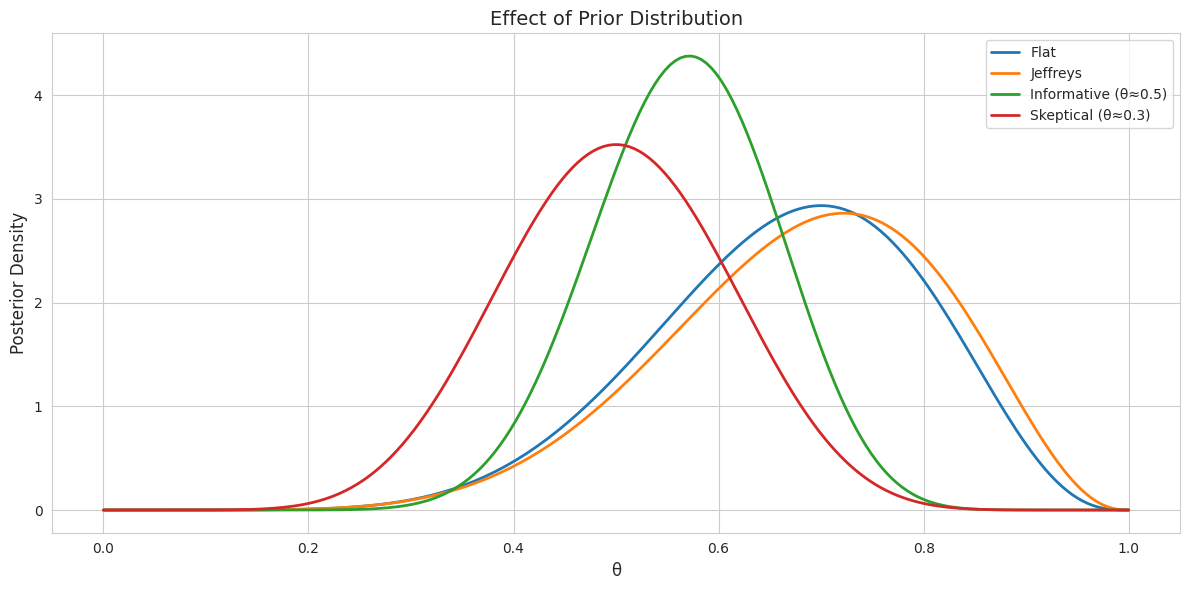

In [8]:
# 事前分布の影響
print("事前分布の感度分析")
print("="*60)

# Data
n = 10
k = 7

# Different priors
priors = [
    ('Flat', 1, 1),
    ('Jeffreys', 0.5, 0.5),
    ('Informative (θ≈0.5)', 10, 10),
    ('Skeptical (θ≈0.3)', 3, 7)
]

fig, ax = plt.subplots(figsize=(12, 6))

print(f"\n{'事前分布':^20} {'事後平均':>10} {'95% CI':>20}")
print("-"*55)

for name, a, b in priors:
    # Posterior
    a_post = a + k
    b_post = b + n - k
    
    post_mean = a_post / (a_post + b_post)
    ci_l = stats.beta.ppf(0.025, a_post, b_post)
    ci_u = stats.beta.ppf(0.975, a_post, b_post)
    
    print(f"{name:^20} {post_mean:>10.3f} [{ci_l:.3f}, {ci_u:.3f}]")
    
    # Plot
    posterior = stats.beta.pdf(theta, a_post, b_post)
    ax.plot(theta, posterior, linewidth=2, label=name)

ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('Effect of Prior Distribution', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 31.6 逐次更新

### ベイズ学習
データが増えるごとに事後分布を更新

今日の事後 = 明日の事前

$$P(\theta | D_1, D_2) \propto P(D_2 | \theta) P(\theta | D_1)$$

逐次更新（ベイズ学習）


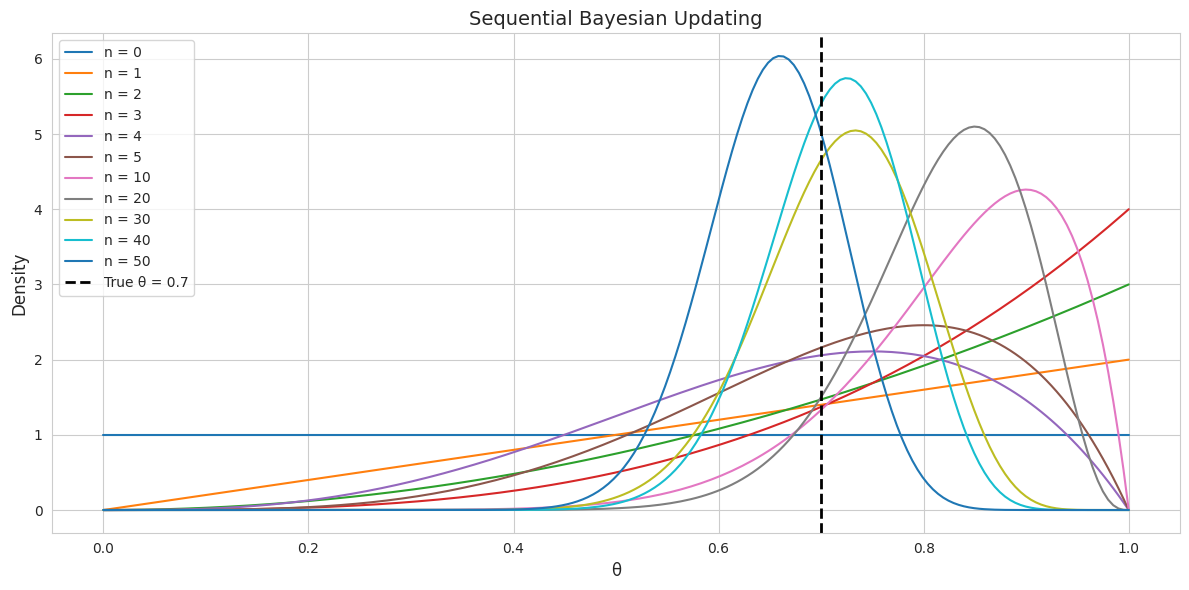

In [9]:
# 逐次更新
print("逐次更新（ベイズ学習）")
print("="*60)

np.random.seed(111)

# True parameter
true_theta = 0.7

# Initial prior
alpha = 1
beta = 1

# Generate sequential data
n_total = 50
data_seq = np.random.binomial(1, true_theta, n_total)

# Track posterior evolution
history = [{'n': 0, 'alpha': alpha, 'beta': beta}]

for i, x in enumerate(data_seq):
    alpha += x
    beta += (1 - x)
    if (i + 1) % 10 == 0 or i < 5:
        history.append({'n': i + 1, 'alpha': alpha, 'beta': beta})

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

for h in history:
    posterior = stats.beta.pdf(theta, h['alpha'], h['beta'])
    ax.plot(theta, posterior, label=f"n = {h['n']}")

ax.axvline(true_theta, color='black', linestyle='--', linewidth=2, label=f'True θ = {true_theta}')
ax.set_xlabel('θ', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sequential Bayesian Updating', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 31.7 練習問題

### 問題1
信用区間と信頼区間の解釈の違いを説明せよ。

### 問題2
共役事前分布を使う利点を3つ挙げよ。

### 問題3
10回のコイン投げで8回表が出た。Beta(2, 2)を事前分布として、θの事後平均と95%信用区間を求めよ。

In [10]:
# 問題1の解答
print("問題1: 信用区間と信頼区間")
print("="*60)

print("""
【信頼区間（頻度論）】
「同じ手順を繰り返すと、95%の区間が真のパラメータを含む」

・パラメータは固定値
・区間が確率変数
・「この区間にθがある確率は95%」とは言えない

【信用区間（ベイズ）】
「データが与えられたとき、θがこの区間にある事後確率は95%」

・パラメータが確率変数
・直接確率的解釈が可能
・P(a < θ < b | D) = 0.95

【実用上の違い】
・ベイズの解釈の方が直感的
・事前情報を組み込める
・小サンプルでも使いやすい
""")

問題1: 信用区間と信頼区間

【信頼区間（頻度論）】
「同じ手順を繰り返すと、95%の区間が真のパラメータを含む」

・パラメータは固定値
・区間が確率変数
・「この区間にθがある確率は95%」とは言えない

【信用区間（ベイズ）】
「データが与えられたとき、θがこの区間にある事後確率は95%」

・パラメータが確率変数
・直接確率的解釈が可能
・P(a < θ < b | D) = 0.95

【実用上の違い】
・ベイズの解釈の方が直感的
・事前情報を組み込める
・小サンプルでも使いやすい



In [11]:
# 問題2の解答
print("問題2: 共役事前分布の利点")
print("="*60)

print("""
【利点】

1. 解析的に事後分布が求まる
   - 積分計算が不要
   - MCMCなどの数値計算が不要
   - 高速で正確

2. 逐次更新が容易
   - ハイパーパラメータを更新するだけ
   - オンライン学習に適する
   - データが増えても計算量一定

3. 解釈しやすい
   - 事前分布のパラメータに意味がある
   - 有効サンプルサイズの概念
   - 例: Beta(a, b)はa-1回の成功とb-1回の失敗に相当

【注意点】
・常に適切とは限らない
・複雑なモデルでは共役が存在しないことも
""")

問題2: 共役事前分布の利点

【利点】

1. 解析的に事後分布が求まる
   - 積分計算が不要
   - MCMCなどの数値計算が不要
   - 高速で正確

2. 逐次更新が容易
   - ハイパーパラメータを更新するだけ
   - オンライン学習に適する
   - データが増えても計算量一定

3. 解釈しやすい
   - 事前分布のパラメータに意味がある
   - 有効サンプルサイズの概念
   - 例: Beta(a, b)はa-1回の成功とb-1回の失敗に相当

【注意点】
・常に適切とは限らない
・複雑なモデルでは共役が存在しないことも



In [12]:
# 問題3の解答
print("問題3: ベイズ推定の計算")
print("="*60)

# Data
n_p3 = 10
k_p3 = 8

# Prior: Beta(2, 2)
alpha_prior_p3 = 2
beta_prior_p3 = 2

# Posterior: Beta(alpha + k, beta + n - k)
alpha_post_p3 = alpha_prior_p3 + k_p3
beta_post_p3 = beta_prior_p3 + n_p3 - k_p3

# Point estimate
post_mean_p3 = alpha_post_p3 / (alpha_post_p3 + beta_post_p3)

# 95% credible interval
ci_lower_p3 = stats.beta.ppf(0.025, alpha_post_p3, beta_post_p3)
ci_upper_p3 = stats.beta.ppf(0.975, alpha_post_p3, beta_post_p3)

print(f"\nデータ: {n_p3}回中{k_p3}回表")
print(f"事前分布: Beta({alpha_prior_p3}, {beta_prior_p3})")
print(f"\n事後分布: Beta({alpha_post_p3}, {beta_post_p3})")
print(f"\n事後平均: {post_mean_p3:.4f}")
print(f"95%信用区間: [{ci_lower_p3:.4f}, {ci_upper_p3:.4f}]")

# Compare with MLE
mle_p3 = k_p3 / n_p3
print(f"\n参考: MLE = {mle_p3:.4f}")
print(f"事後平均はMLEと事前平均(0.5)の間に縮小")

問題3: ベイズ推定の計算

データ: 10回中8回表
事前分布: Beta(2, 2)

事後分布: Beta(10, 4)

事後平均: 0.7143
95%信用区間: [0.4619, 0.9091]

参考: MLE = 0.8000
事後平均はMLEと事前平均(0.5)の間に縮小


## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---